[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [12]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [13]:
from obspy import read, Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import stft

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import pandas as pd
import pickle as pk
import copy

np.random.seed(42)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# KVG Catalog

## Stations

### Retrieve Coordinates

In [ ]:
client = Client("https://geofon.gfz-potsdam.de")
tstart = UTCDateTime("2015-07-01 00:00:00")
tend   = UTCDateTime("2016-07-31 00:00:00")

inv = client.get_stations(network="X9",  starttime=tstart, endtime=tend, channel="*HN")
# print(inv)
nsta = np.shape(inv)[1]

# stla = np.zeros(nsta)
# stlo = np.zeros(nsta)
coordinates_for_station = {}

for i in range(0,nsta):
    coordinates_for_station[inv[0][i].code] = [inv[0][i].latitude,inv[0][i].longitude]
stname = list(coordinates_for_station.keys())

## Catalog

In [ ]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
print(f"Time range: {catalog['time'].min()} to {catalog['time'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} – {catalog['mag'].max():.1f}")
catalog.head()

Loaded 11209 events
Time range: 2015-08-03 14:56:47.810000+00:00 to 2016-07-04 21:46:56.760000+00:00
Magnitude range: 0.0 – 3.1


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


## Phase Data

In [ ]:
stations_for_event = {}
Event_per_station = {}
i=0
with open("/content/Thesis/KVG_phase_data.txt", "r", encoding="UTF-8") as f:
    date = -1
    line = f.readline()

    while line != "":
        check = line[:2]
        match check:
            case "X9":
                datas = line.split(",")
                #                                              NOME STAZIONE     P TIME   S TIME
                stations_for_event.setdefault(f"Event {i}", {})[datas[0][3:]] = (datas[1],datas[2])
                Event_per_station.setdefault(datas[0][3:], []).append(f"Event {i}")

            case "D0":
                pass

            case _:
                date = line.split(",")[0]
                i+=1
        line = f.readline()

# Preparing Dataset

## Pre e Post Events

In [ ]:
cutoff = pd.Timestamp("2016-04-21", tz="UTC")
ses = catalog[catalog["time"] > cutoff]

Eventi_Post_Eruzione = ses.index.tolist()

Stazioni_post = []
for E in Eventi_Post_Eruzione:
  Stazioni_post += list(stations_for_event[E].keys())

Stazioni_post = list(set(Stazioni_post))

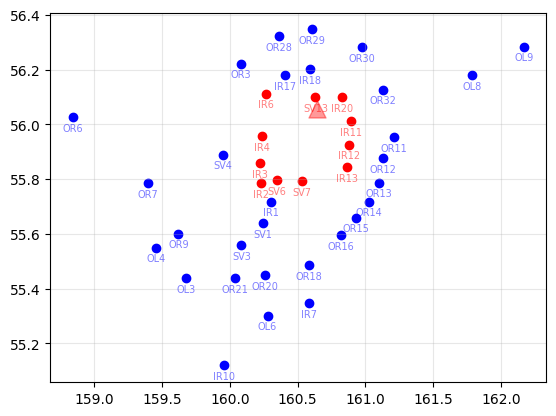

In [ ]:
# Event_per_station Dizionario dove per chiave ho il nome della stazione e valore la lista degli eventi registrati
Stazioni_da_usare = ["SV13", "SV6", "SV7", "IR2", "IR3", "IR4", "IR6", "IR20", "IR11", "IR12", "IR13"]
Klyuchevskoy = {"lon" : 56.056,
                "lat" : 160.642}


for St in list(Stazioni_post):
  color = "red" if St in Stazioni_da_usare else "blue"

  lat, lon = coordinates_for_station[St][0], coordinates_for_station[St][1]
  plt.scatter(lon, lat, marker="o", color=color)
  plt.annotate(St, (lon, lat), textcoords="offset points", xytext=(0, -10), ha="center", fontsize=7, color=color, alpha = 0.5)

plt.scatter(Klyuchevskoy["lat"], Klyuchevskoy["lon"], marker="^", s=150, color="red", alpha = 0.4)

plt.scatter([], [], marker="^", color="red", label="Klyuchevskoy Volcano")
plt.scatter([], [], marker="o", color="red", label="Stations that don't have Post-Eruption Registrations")
plt.scatter([], [], marker="o", color="blue", label="Stations that have Post-Eruption Registrations")

# plt.legend()
plt.grid("on",alpha=0.3)
# plt.savefig("Stazioni Evidenziate che hanno registrato il post eruzione.png")

plt.show()

In [ ]:
# Maschera per PRE-Eruzione
n_PRE_Events = 480
end   = pd.Timestamp("2016-04-20", tz="UTC")

mask = catalog["time"] <= end
catalog_PRE = catalog[mask].index.tolist()
catalog_PRE = list(np.random.choice(catalog_PRE, size=n_PRE_Events, replace=False))
PRE_Eruption = []

for ev in catalog_PRE:
    Stazioni_Disponibili = list(stations_for_event[ev].keys())
    if not Stazioni_Disponibili:
        continue
    n = min(4, len(Stazioni_Disponibili))
    scelte = np.random.choice(Stazioni_Disponibili, size=n, replace=False)
    PRE_Eruption += [(st, ev) for st in scelte]

# Maschera per POST-Eruzione
start = pd.Timestamp("2016-04-21", tz="UTC")
# end   = pd.Timestamp("2016-06-05", tz="UTC")

mask = (catalog["time"] >= start) #& (catalog["time"] <= end)
catalog_POST = catalog[mask].index.tolist()
POST_Eruption = []

for stazione in Stazioni_da_usare:
  POST_Eruption += [(stazione, ev) for ev in catalog_POST if ev in set(Event_per_station[stazione])]

print(len(PRE_Eruption),len(POST_Eruption))

1917 1890


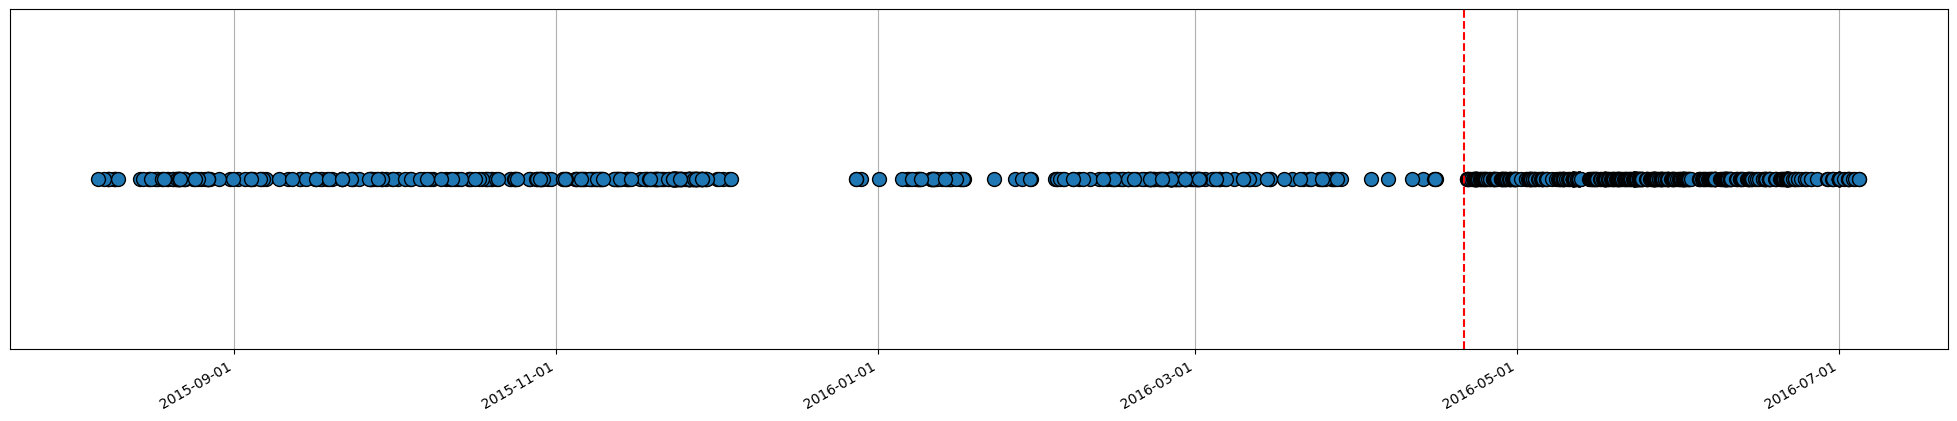

In [ ]:
Tutti_gli_eventi = catalog_PRE + catalog_POST
tempi = catalog.loc[Tutti_gli_eventi, "time"]

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi, [0]*len(tempi), "o",ms = 10, markerfacecolor="C0", markeredgecolor="black", markeredgewidth=1)

ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
ax.grid("on")
fig.autofmt_xdate()
plt.show()

In [ ]:
end   = pd.Timestamp("2016-04-20", tz="UTC")

mask = catalog["time"] <= end
catalog_PRE = catalog[mask].index.tolist()
PRE_Eruption = []

for ev in catalog_PRE:
    Stazioni_Disponibili = list(stations_for_event[ev].keys())
    if not Stazioni_Disponibili:
        continue

    scelte = [st for st in Stazioni_Disponibili if st in Stazioni_post]
    PRE_Eruption += [(st, ev) for st in scelte]

In [18]:
len(PRE_Eruption[46993:])

66556

In [19]:
import os, pickle, time
from concurrent.futures import ThreadPoolExecutor
from obspy.clients.fdsn.header import (
    FDSNNoDataException, FDSNServiceUnavailableException)

pre_time, post_time = 2, 18
CHECKPOINT = "/content/drive/MyDrive/Datasets/events_checkpoint_2.pkl"

# Riprendi da un checkpoint se esiste
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT, "rb") as f:
        Events = pickle.load(f)
    done = {(St, E) for St, E, _ in Events}
    print(f"Ripreso: {len(Events)} già scaricati")
else:
    Events, done = [], set()

todo = [item for item in PRE_Eruption if item not in done]

def fetch(item, max_retries=5):
    St, E = item
    T = UTCDateTime(stations_for_event[E][St][0])
    for attempt in range(max_retries):
        try:
            reg = client.get_waveforms(
                network="X9", station=St, location="*", channel="*",
                starttime=T - pre_time, endtime=T + post_time)
            return (St, E, reg)
        except FDSNNoDataException:
            return (St, E, None)
        except FDSNServiceUnavailableException:
            time.sleep(2 ** attempt)
    return (St, E, "FAILED")

n = len(PRE_Eruption)
with ThreadPoolExecutor(max_workers=4) as ex:
    for i, (St, E, reg) in enumerate(ex.map(fetch, todo), 1):
        if reg is not None and reg != "FAILED":
            Events.append((St, E, reg))
        # salva ogni 500 scaricati
        if not i % 500:
            with open(CHECKPOINT, "wb") as f:
                pickle.dump(Events, f)
            print(f"{len(Events)}/{n} salvati")

# salvataggio finale
with open(CHECKPOINT, "wb") as f:
    pickle.dump(Events, f)

Ripreso: 46993 già scaricati
47487/113549 salvati
47987/113549 salvati
48487/113549 salvati
48987/113549 salvati
49487/113549 salvati
49987/113549 salvati
50487/113549 salvati
50987/113549 salvati
51486/113549 salvati
51986/113549 salvati
52486/113549 salvati
52986/113549 salvati
53486/113549 salvati
53986/113549 salvati
54486/113549 salvati
54986/113549 salvati
55486/113549 salvati
55986/113549 salvati
56486/113549 salvati
56986/113549 salvati
57486/113549 salvati
57986/113549 salvati
58486/113549 salvati
58986/113549 salvati
59486/113549 salvati
59986/113549 salvati
60486/113549 salvati
60986/113549 salvati
61486/113549 salvati
61986/113549 salvati
62486/113549 salvati
62986/113549 salvati
63486/113549 salvati
63986/113549 salvati
64486/113549 salvati
64986/113549 salvati
65486/113549 salvati
65986/113549 salvati
66486/113549 salvati
66986/113549 salvati
67486/113549 salvati
67986/113549 salvati
68486/113549 salvati
68986/113549 salvati


FDSNException: Unknown Error (RemoteDisconnected): Remote end closed connection without response

## Retrieve Data and Filtering

In [ ]:
# lunghezza temporale dell'onda
# 23 min per 2050
# 34 min per 3000 circa
pre_time   = 2
Post_time  = 18

Events = []
Dataset_By_Event   = {}
Dataset_By_Station = {}
labels = []                       # 0 = pre, 1 = post
POST_set = set(E for (St, E) in POST_Eruption)
n = len(PRE_Eruption) + len(POST_Eruption)
# for index, Tmp in enumerate(PRE_Eruption + POST_Eruption):
#     St, E = Tmp
#     T = UTCDateTime(stations_for_event[E][St][0])
#     try:
#         Reg = client.get_waveforms(
#             network="X9",
#             station=St,
#             location="*",
#             channel="*",
#             starttime=T - pre_time,
#             endtime=T + Post_time)

#         pos = len(Events)                 # indice reale in Events
#         Events.append((St, E, Reg))
#         labels.append(1 if E in POST_set else 0)
#         Dataset_By_Station.setdefault(St, []).append(pos)
#         Dataset_By_Event.setdefault(E, []).append(pos)

#     except FDSNNoDataException:
#         print(f"Errore per {E} nella stazione {St}\n")
#         continue
#     if not (index + 1) % 50: print(f"{index + 1}: {((index + 1)/n * 100):.2f}%  Fatti. ")

In [ ]:
# Events = [(St, E, D) for (St, E, D) in Events if all(tr.stats.npts >= 1000 for tr in D)]

# # Smoothing
# for _, _, st in Events:
#   for tr in st:

#     tr.detrend("demean")
#     tr.detrend("linear")

#     tr.filter(
#         "bandpass",
#         freqmin=1,
#         freqmax=20,
#         corners=4,
#         zerophase=True)

In [ ]:
# with open("Dataset_Tesi.pkl", "wb") as f:
#     pk.dump(Events, f, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
with open("/content/drive/MyDrive/Datasets/Dataset_Tesi.pkl", "rb") as f:
    Events = pk.load(f)

In [ ]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
groups_ev = np.array([E for (St, E, D) in Events])   # Estraggo l'evento per ogni Dato (ordinato per indice)

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

In [ ]:
for nome, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    lab = y[idx]
    print(f"{nome}: Eventi Post = {lab.sum()}, Eventi Pre = {len(lab)-lab.sum()}, Proporzione eventi post = {lab.mean():.3f}")

train: Eventi Post = 1490, Eventi Pre = 1535, Proporzione eventi post = 0.493
val: Eventi Post = 199, Eventi Pre = 185, Proporzione eventi post = 0.518
test: Eventi Post = 200, Eventi Pre = 194, Proporzione eventi post = 0.508


# CNN1D

In [ ]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [ ]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True)
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [ ]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # In caso prova anche un Flatten
            nn.AdaptiveAvgPool1d(1),   # riduce l'asse temporale a 1
        )
        # self.dropout = nn.Dropout(0.3)
        self.Dropout = nn.Dropout(0.3)
        self.lin = nn.Linear(128, output_classes)

    def forward(self, x):            # x: (batch, in_channels, lunghezza)
        x = self.features(self.Dropout(x))
        x = x.flatten(1)
        return self.lin(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 50
OneD_model = CNN().to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10)

In [ ]:
history1D = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}
best_val_acc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    OneD_model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    # scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val accuracy: {best_val_acc:.4f}")

Training:  50%|█████     | 25/50 [00:30<00:28,  1.13s/it]


Epoch 25: 
train_loss=0.3274 
train_acc=0.8625 
val_loss=0.9596 
val_acc=0.737


Training: 100%|██████████| 50/50 [00:59<00:00,  1.20s/it]


Epoch 50: 
train_loss=0.2580 
train_acc=0.8932 
val_loss=1.6284 
val_acc=0.698
Best val accuracy: 0.7943


# CNN2D

In [ ]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [ ]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [ ]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),   # riduce l'asse temporale a 1
        )
        self.Dropout = nn.Dropout(0.5)
        self.lin = nn.Linear(128, output_classes)

    def forward(self, x):
        x = self.features(self.Dropout(x))
        x = x.flatten(1)
        return self.lin(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(TwoD_model.parameters(), lr=1e-4)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10)

In [ ]:
history2D = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}
best_val_acc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    # scheduler.step(val_loss)   # da attivare con lo scheduler

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Training:  25%|██▌       | 25/100 [02:18<07:02,  5.64s/it]


Epoch 25: 
train_loss=0.1984 
train_acc=0.9283 
val_loss=1.1376 
val_acc=0.695


Training:  50%|█████     | 50/100 [04:33<04:30,  5.40s/it]


Epoch 50: 
train_loss=0.1584 
train_acc=0.9418 
val_loss=1.0122 
val_acc=0.737


Training:  75%|███████▌  | 75/100 [06:47<02:14,  5.37s/it]


Epoch 75: 
train_loss=0.1307 
train_acc=0.9481 
val_loss=1.1920 
val_acc=0.732


Training: 100%|██████████| 100/100 [09:01<00:00,  5.41s/it]


Epoch 100: 
train_loss=0.1138 
train_acc=0.9547 
val_loss=1.4917 
val_acc=0.703

Best val accuracy: 0.8281


# Results Plots

In [ ]:
# Parla di come splitti gli eventi
# Prendi sempre eventi pre casuali, non sempre gli stessi prima così puoi differenziare tra le stazioni e gli eventi, magari capisce qualcosa in più sul pre e classifica meglio

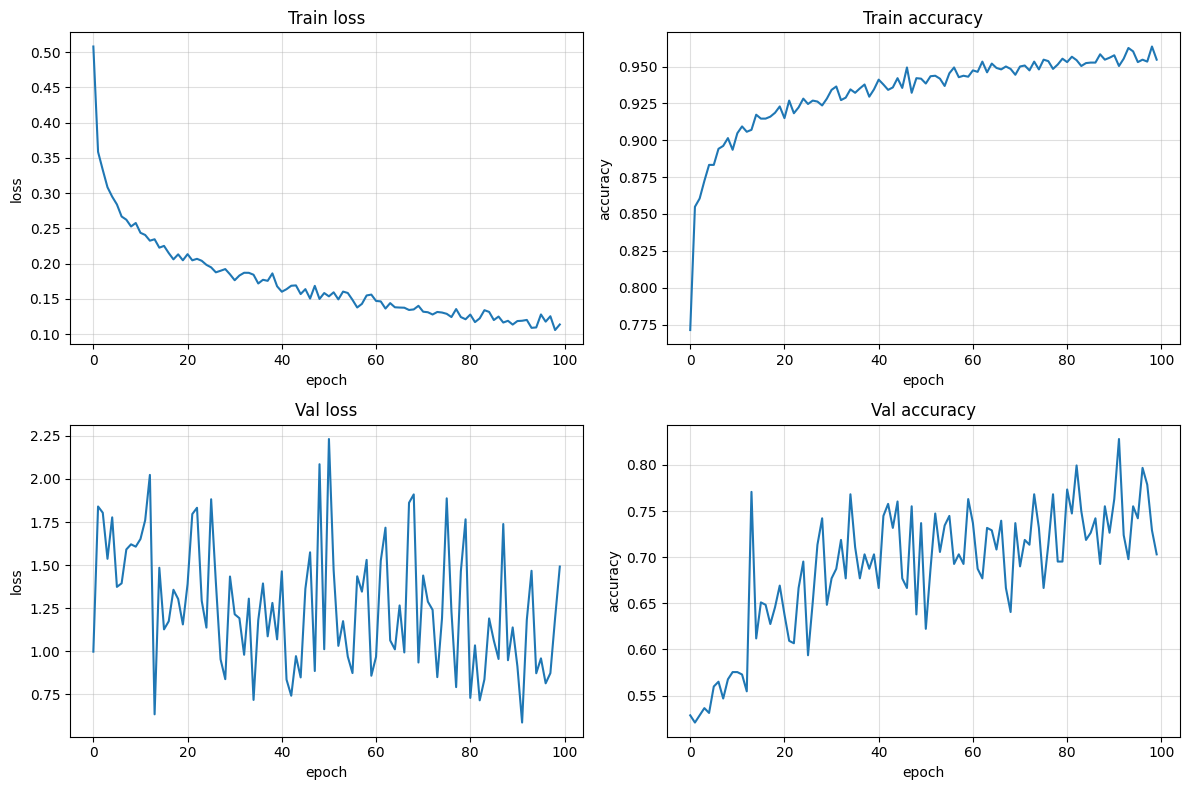

In [ ]:
# history, Using, model = history1D, "CNN1D", OneD_model

history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(history["train_loss"])
ax[0, 0].set_title("Train loss")
ax[0, 0].set_xlabel("epoch"); ax[0, 0].set_ylabel("loss")
ax[0, 0].grid(alpha = 0.4)

ax[0, 1].plot(history["train_acc"])
ax[0, 1].set_title("Train accuracy")
ax[0, 1].set_xlabel("epoch"); ax[0, 1].set_ylabel("accuracy")
ax[0, 1].grid(alpha = 0.4)

ax[1, 0].plot(history["val_loss"])
ax[1, 0].set_title("Val loss")
ax[1, 0].set_xlabel("epoch"); ax[1, 0].set_ylabel("loss")
ax[1, 0].grid(alpha = 0.4)

ax[1, 1].plot(history["val_acc"])
ax[1, 1].set_title("Val accuracy")
ax[1, 1].set_xlabel("epoch"); ax[1, 1].set_ylabel("accuracy")
ax[1, 1].grid(alpha = 0.4)

fig.tight_layout()
# fig.savefig(f"{Using}: Train and Validation set during Training.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def get_preds(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

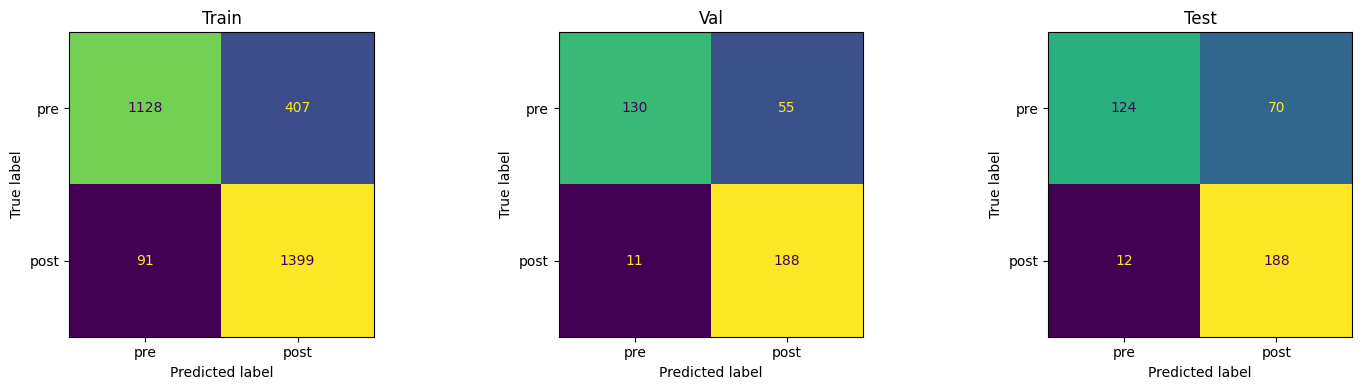

In [ ]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]        # 0 = pre, 1 = post
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_title(name)

fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
model.eval()
tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)
test_acc = (yt == yp).mean()
print(f"Test accuracy for {Using}: {test_acc:.4f}")
# print(history)

Test accuracy for CNN2D: 0.7919


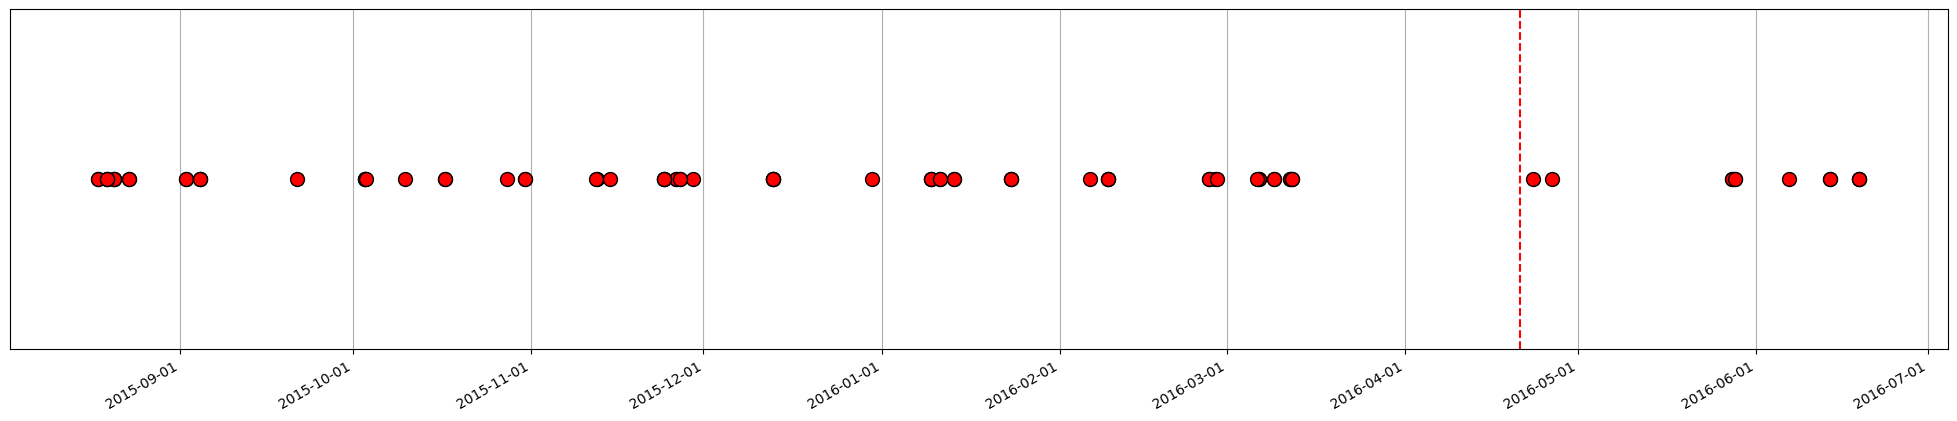

In [ ]:
mis_idx = np.where(yt != yp)[0]

test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events

Eventi_Errati = []
for i in mis_idx:
    Eventi_Errati.append(test_events[i][1])

tempi = catalog.loc[Eventi_Errati, "time"]

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi, [0]*len(tempi), "o",color = "red", ms = 10, markeredgecolor="black", markeredgewidth=1)
ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
ax.grid("on")
fig.autofmt_xdate()
plt.show()